**Problem 1 (40 pontos)**

Consider the following two AR processes, with zero initial conditions and **w** being white noise with a uniform distribution, zero mean, and variance equal to 2.

$$
(I)\ x(k) = w(k) + 3/2x(k-1) - x(k-2) + 1/4x(k-3)
$$
$$
(II)\ x(k) = w(k) + 3/2x(k-1) - 1/2x(k-2) + 3/4x(k-3)
$$

a) From the characteristic polynomials, draw conclusions about the stability of these systems.

**Process (I)**
$$
x(k) = w(k) + 3/2x(k-1) - x(k-2) + 1/4x(k-3)
$$
$$
w(k) = x(k) - 3/2x(k-1) + x(k-2) - 1/4x(k-3)
$$
$$
C(z) = z^3 - 3/2z^2 + z - 1/4 = 0 \implies z = 0.5 \ and \ z = \frac{1 \pm \sqrt{1-2}}{2} =  \frac{1 \pm i}{2} = 0.5 \pm 0.5i
$$

**Process (II)**
$$
x(k) = w(k) + 3/2x(k-1) - 1/2x(k-2) + 3/4x(k-3)
$$
$$
w(k) = x(k) - 3/2x(k-1) + 1/2x(k-2) - 3/4x(k-3)
$$
$$
C(z) = z^3 - 3/2z^2 + 1/2z - 3/4 = 0 \implies z = 1.5 \ and \ z = \pm i \sqrt{0.5} = \pm0.7071i
$$





b) Study the stability of the same systems using a simulation approach.

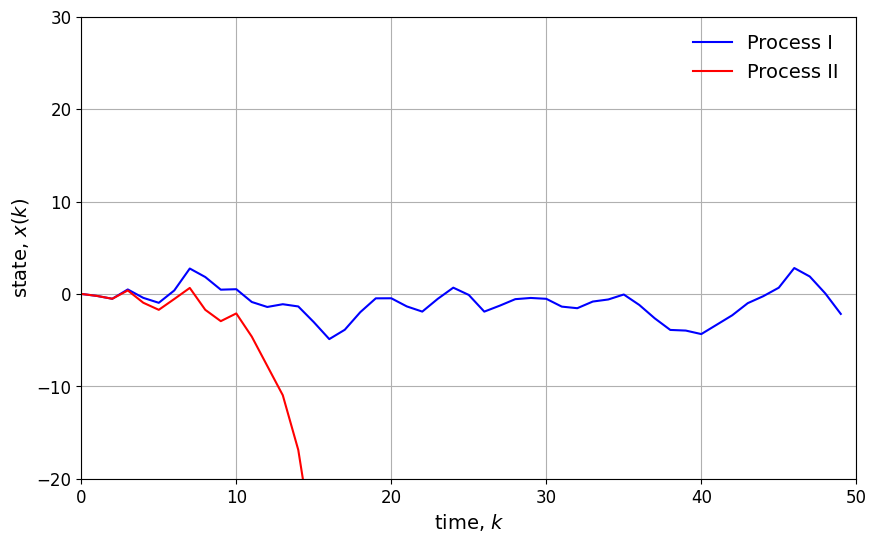

In [8]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

# seed
seed = 7
np.random.seed(seed)

# parameters
h = 1
Z = 50
N = int(Z/h)

t = np.zeros(N)
w = np.zeros(N)
a = np.zeros(N)
b = np.zeros(N)

# AR processes
for k in range(N):
    w[k] = np.sqrt(-2 * np.log(np.random.random_sample()))\
       * np.cos(2 * np.pi * np.random.random_sample())
    if (k >= 3):
        a[k] = w[k] + 3/2 * a[k-1] - a[k-2] + 1/4 * a[k-3]
        b[k] = w[k] + 3/2 * b[k-1] - 1/2 * b[k-2] + 3/4 * b[k-3]
    elif (k >= 2):
        a[k] = w[k] + 3/2 * a[k-1] - a[k-2] 
        b[k] = w[k] + 3/2 * b[k-1] - 1/2 * b[k-2]
    elif (k >= 1):
        a[k] = w[k] + 3/2 * a[k-1]
        b[k] = w[k] + 3/2 * b[k-1]
    t[k] = h * k


# Figure
plt.figure(figsize=(10, 6))
plt.plot(t, a,"b-",label = "Process I")
plt.plot(t, b,"r-",label = "Process II")
plt.xlabel("time, $k$",fontsize=14)
plt.ylabel(r"state, $x(k)$",fontsize=14)
plt.legend(prop={"size":14},frameon=False)
plt.axis([0, 50, -20, 30])
plt.grid()
plt.show()

**Comments**

The plot shows that process I (blue line) remain bounded around zero, exhibiting a lightly damped oscillatory behavior. Over time, the fluctuations do not grow, giving the appearance of a stationary AR process. 

In contrast, process II (red line) becomes unstable due to the presence of a real root at 1.5, which is greater than 1. As a consequence, the response grows rapidly in magnitude within 25 samples rather than decaying. Since its characteristic root lies outside the unit circle, the process is classified as unstable

c) Analyze the results and provide the proper comments.

**Process I**

Process I is stationary (stable) because its AR roots are 0.5 and $0.5\pm 0.5i$, whose magnitudes are 0.5 and $\sqrt{0.5}\approx0.7071 < 1$.

The complex pair implies a lightly damped oscillation (angle $\pi/4rad/sample$ $\implies$ period $\approx 8$ samples).


**Process II**

Regarding process II, this process is non-stationary (unstable) because one AR root is 1.5 (magnitude $>$ 1), while the other two are $\pm 0.7071i\ (magnitude \approx 0.7071<1)$.

The complex pair would produce a damped oscillation at $\omega=\pi/2rad/sample (period \approx 4 samples)$, but the real pole at 1.5 causes exponential growth and, thus it can not be considered a stable process.


**Problem 2 (60 pontos)**

Model the following autocorrelation data as an AR process of:

| $\tau$ | $R_{xx}(\tau)$ |
| --- |---|
| 0 | 10.0 |
| 1 | 7.0 |
| 2 | 6.5 |
| 3 | 5.5 |
| 4 | 6.0 |
| 5 | 4.0 |
| 6 | 2.0 |
| 7 | 1.0 |

a) First-order;

b) Second-order;

c) Third-order.

For each model, compare the predicted autocorrelation values ​​with the original data. Begin by modeling the process and then create a simulation instance. 

From the simulation results, calculate the autocorrelation coefficients and variance.

Compare them with the original data, and provide the proper comments.

In [9]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

#  seed
seed = 7    
np.random.seed(seed)

# parameters R_xx(tau)
R = np.array([10.0, 7.0, 6,5, 5.5, 6.0, 4.0, 2.0, 1.0])

In [10]:
# White Gaussian Noise
def ruido_uniforme(N, var):
    a = np.sqrt(3.0 * var)
    return a * (2*np.random.random_sample(N) - 1.0)

# Yule-Walker equations to estimate AR
def yule_walker(R, p):
    T = np.array([[R[abs(i-j)] for j in range(p)] for i in range(p)], dtype=float)
    r = R[1:p+1]
    a = np.linalg.solve(T, r)
    sigma2 = R[0] - np.dot(a, R[1:p+1])
    return a, float(sigma2)

#  Autoregressive (AR) process
def simula_ar(a, N, var):
    p, x, w = len(a), np.zeros(N), ruido_uniforme(N, var)
    for k in range(N):
        x[k] = w[k] + sum(a[i] * (x[k-1-i] if k-1-i >= 0 else 0.0) for i in range(p))
    return x

# autocorrelation function
def acf_nao_viesada(x, max_lag):
    x = x - np.mean(x)
    N = len(x)
    return np.array([np.dot(x[:N-L], x[L:])/(N-L) for L in range(max_lag+1)])

The lag indices are [0 1 2 3 4 5 6 7]
Q2 - AR(1): a = [0.7]  | sigma_w^2 = 5.1000000000000005
Q2 - AR(2): a = [0.54901961 0.21568627]  | sigma_w^2 = 4.862745098039215
Q2 - AR(3): a = [0.54032258 0.19354839 0.04032258]  | sigma_w^2 = 4.85483870967742


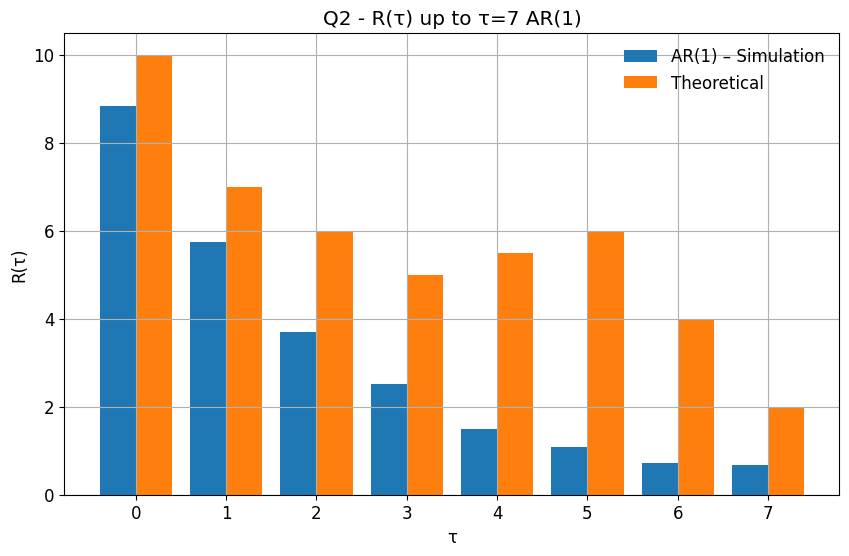

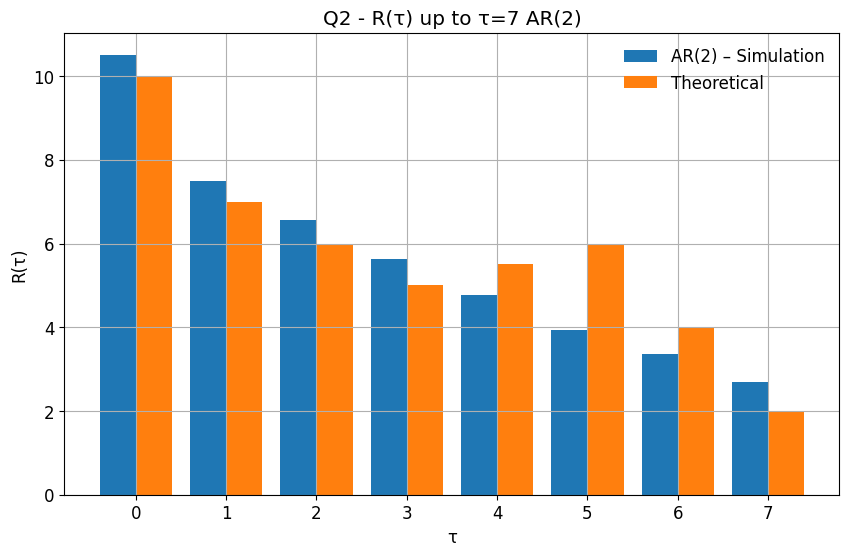

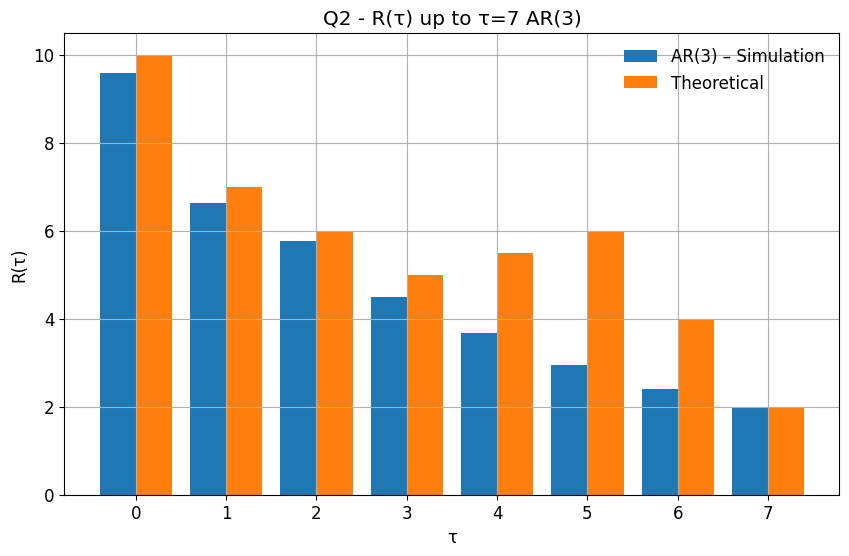

In [11]:
# Sets up parameters for analyzing AR model data
N = 1000 # number of samples
max_lag = 7 # maximum lag
Rref = R[:8] # reference data
lags = np.arange(0, 8) # lags
print(f'The lag indices are {lags}')

# AR Model
a1, s2_1 = yule_walker(R, 1) # AR(1) model
a2, s2_2 = yule_walker(R, 2) # AR(2) model
a3, s2_3 = yule_walker(R, 3) # AR(3) model
print("Q2 - AR(1): a =", a1, " | sigma_w^2 =", s2_1) # Single coefficient + noise variance
print("Q2 - AR(2): a =", a2, " | sigma_w^2 =", s2_2) # Two coefficient + noise variance
print("Q2 - AR(3): a =", a3, " | sigma_w^2 =", s2_3) # Three coefficient + noise variance

# Function comparing theoretical vs simulated autocorrelation for AR models
def compara(nome, a, s2):
    x = simula_ar(list(a), N, s2)
    R_est = acf_nao_viesada(x, 7)
    plt.figure(figsize=(10, 6))
    plt.bar(lags - 0.2, R_est, width=0.4, label=f"{nome} – Simulation")
    plt.bar(lags + 0.2, Rref, width=0.4, label="Theoretical")
    plt.title(f"Q2 - R(τ) up to τ=7 {nome}")
    plt.xlabel("τ")
    plt.ylabel("R(τ)")
    plt.grid()
    plt.legend(frameon=False)
    plt.show()

compara("AR(1)", a1, s2_1) # Compare AR(1) model 
compara("AR(2)", a2, s2_2) # Compare AR(2) model 
compara("AR(3)", a3, s2_3) # Compare AR(3) model 

**Comments**

*AR(1) process* 

- Coefficient - a = [0.7000]

- Variance - 5.1000

This process captures the initial decay observed in the theoretical response, but it fails to reproduce its shape in the later samples. As a result, the correlation between the theoretical and simulated values appears to be adequate in the final portion of the signal.    

*AR(2) process* 

- Coefficients - a = [0.5490 0.2156]

- Variance - 4.8627

The AR(2) process appears to capture the decay across the entire signal. In addition, the simulated values closely match those of the theoretical response, indicating that the AR(2) model provides an adequate stochastic data representation.

*AR(3) process* 

- Coefficients - a = [0.5403 0.1935 0.0403]

- Variance - 4.8548

Similar to the AR(2) process, the AR(3) model captures the decay across the entire signal, with simulated values closely matching the theoretical response. This indicates that the AR(3) model also provides an adequate stochastic data representation.

**In conclusion**

Among the models evaluated, the AR(1) process reproduces only the initial decay of the theoretical signal, while the AR(2) and AR(3) models closely match the full behavior of the response, offering more accurate and reliable stochastic representations. Finally, it is noteworthy that the AR(3) model did not provide a meaningful improvement over the AR(2) model (variance: AR(2) = 4.86 vs. AR(3) = 4.85), indicating that a second-order AR process is sufficient to generate an accurate simulated values.